## Projet 7 : Réalisez une analyse de sentiments grâce au Deep Learning

## Contexte

Vous êtesingénieur IA chez "Marketing Intelligence Consulting", une entreprise de conseil spécialisée sur les problématiques de marketing digital.

"Air Paradis" a missionné votre cabinet pour créer un produit IA permettant d’anticiper les bad buzz sur les réseaux sociaux en permettant de prédire le sentiment associé à un tweet.

Marc, votre manager, vous demande de tester plusieurs approches :
- approche “Modèle sur mesure simple”, pour développer rapidement un modèle classique (ex : régression logistique) permettant de prédire le sentiment associé à un tweet.
- approche “Modèle sur mesure avancé” pour développer un modèle basé sur des réseaux de neurones profonds pour prédire le sentiment associé à un tweet. => C’est ce modèle qui sera déployé et montré à Air Paradis.

Une démarche MLOPS devra être mis en oeuvre.

Le déploiement selon un pipeline continu du modèle via API intègrera également des tests unitaires automatisés.

Un suivi de performance du modèle en production sera également mis en place.

## Librairies utilisées avec le langage Python :

In [22]:
# Importation des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import ast
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_score
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, roc_auc_score, accuracy_score, make_scorer
import mlflow
import mlflow.sklearn
import shutil
from IPython.display import FileLink
from pyngrok import ngrok
import gc
import os
import subprocess
import webbrowser
import time
import warnings
warnings.filterwarnings('ignore')


In [2]:
# RaZ des runs mlflow
# shutil.rmtree('D:/tutorial-env/OCR/Projet7/mlruns', ignore_errors=True)

# Création répertoire local pour les logs MLFlow
local_path = "D:/tutorial-env/OCR/Projet7/mlruns"
os.makedirs(local_path,exist_ok=True)

mlflow.set_tracking_uri(f"file:///{local_path}")
mlflow.set_experiment("test_RL")

<Experiment: artifact_location='file:///D:/tutorial-env/OCR/Projet7/mlruns/880161166231324753', creation_time=1736765872963, experiment_id='880161166231324753', last_update_time=1736765872963, lifecycle_stage='active', name='test_RL', tags={}>

## Données :

In [3]:
# Importation de data :
X_train = pd.read_csv('D:/tutorial-env/OCR/Projet7/csv_p7_Xtrain_preprocessed.csv')
X_test = pd.read_csv('D:/tutorial-env/OCR/Projet7/csv_p7_Xtest_preprocessed.csv')


In [4]:
X_train.head()

,target,text,len_text,tweet_preprocess,token_by_tweet_temp,token_by_tweet_finalised,token_by_tweet_temp_sans_racinisation,token_by_tweet_finalised_sans_racinisation
0,1,I wanna in queue 2! I even registered 2 buy it...,74,I wanna in queue 2! I even registered 2 buy it...,"['wanna', 'queue', 'even', 'regist', 'buy', 'h...","['wanna', 'queue', 'even', 'regist', 'buy', 'h...","['wanna', 'queue', 'even', 'registered', 'buy'...","['wanna', 'queue', 'even', 'buy', 'forgot', 'q..."
1,0,So no-one is coming with me Damn..,35,So no-one is coming with me Damn..,"['one', 'come', 'damn', 'one_com', 'coming_dam...","['one', 'come', 'damn', 'one_com', 'coming_damn']","['one', 'coming', 'damn', 'one_coming', 'comin...","['one', 'damn', 'coming_damn']"
2,0,@dmbdork live and learn screw you Stanley Ste...,56,live and learn screw you Stanley Steemer!!!,"['live', 'learn', 'screw', 'stanley', 'steemer...","['live', 'learn', 'screw', 'stanley', 'steemer...","['live', 'learn', 'screw', 'stanley', 'steemer...","['live', 'learn', 'screw', 'stanley', 'steemer..."
3,1,I want to watch fight club with u!,35,I want to watch fight club with u!,"['want', 'watch', 'fight', 'club', 'want_watch...","['want', 'watch', 'fight', 'club', 'want_watch...","['want', 'watch', 'fight', 'club', 'want_watch...","['want', 'watch', 'fight', 'club', 'want_watch..."
4,1,10 more CD's and then I'm done the good new al...,126,10 more CD's and then I'm done the good new al...,"['done', 'new', 'album', 'upload', 'new', 'mac...","['done', 'new', 'album', 'upload', 'new', 'mac...","['done', 'new', 'albums', 'uploaded', 'new', '...","['done', 'new', 'new', 'macbook', 'gone', 'yet..."


In [5]:
typ = type(X_train['token_by_tweet_finalised'][0])
print(f'le type de la colonne token_by_tweet_finalised est :{typ}')

le type de la colonne token_by_tweet_finalised est :<class 'str'>


On va transformer la chaine de caractère en liste de tokens comme initialement, puis on les retransformera en chaine de caractères sans les "codes" de la liste ( [ , ' )

In [6]:
# Conversion en liste de tokens (et non plus str) comme initialement
X_train['token_by_tweet_finalised'] = X_train['token_by_tweet_finalised'].apply(lambda x: ast.literal_eval(x))
X_test['token_by_tweet_finalised'] = X_test['token_by_tweet_finalised'].apply(lambda x: ast.literal_eval(x))

X_train['token_by_tweet_finalised_sans_racinisation'] = X_train['token_by_tweet_finalised_sans_racinisation'].apply(lambda x: ast.literal_eval(x))
X_test['token_by_tweet_finalised_sans_racinisation'] = X_test['token_by_tweet_finalised_sans_racinisation'].apply(lambda x: ast.literal_eval(x))

X_train.head()

,target,text,len_text,tweet_preprocess,token_by_tweet_temp,token_by_tweet_finalised,token_by_tweet_temp_sans_racinisation,token_by_tweet_finalised_sans_racinisation
0,1,I wanna in queue 2! I even registered 2 buy it...,74,I wanna in queue 2! I even registered 2 buy it...,"['wanna', 'queue', 'even', 'regist', 'buy', 'h...","[wanna, queue, even, regist, buy, howev, forgo...","['wanna', 'queue', 'even', 'registered', 'buy'...","[wanna, queue, even, buy, forgot, queue_even]"
1,0,So no-one is coming with me Damn..,35,So no-one is coming with me Damn..,"['one', 'come', 'damn', 'one_com', 'coming_dam...","[one, come, damn, one_com, coming_damn]","['one', 'coming', 'damn', 'one_coming', 'comin...","[one, damn, coming_damn]"
2,0,@dmbdork live and learn screw you Stanley Ste...,56,live and learn screw you Stanley Steemer!!!,"['live', 'learn', 'screw', 'stanley', 'steemer...","[live, learn, screw, stanley, steemer, live_le...","['live', 'learn', 'screw', 'stanley', 'steemer...","[live, learn, screw, stanley, steemer, live_le..."
3,1,I want to watch fight club with u!,35,I want to watch fight club with u!,"['want', 'watch', 'fight', 'club', 'want_watch...","[want, watch, fight, club, want_watch, watch_f...","['want', 'watch', 'fight', 'club', 'want_watch...","[want, watch, fight, club, want_watch, watch_f..."
4,1,10 more CD's and then I'm done the good new al...,126,10 more CD's and then I'm done the good new al...,"['done', 'new', 'album', 'upload', 'new', 'mac...","[done, new, album, upload, new, macbook, gone,...","['done', 'new', 'albums', 'uploaded', 'new', '...","[done, new, new, macbook, gone, yet, though, d..."


In [7]:
typ = type(X_train['token_by_tweet_finalised'][0])
print(f'le type de la colonne token_by_tweet_finalised est :{typ}')

le type de la colonne token_by_tweet_finalised est :<class 'list'>


In [8]:
# Convertir les listes de tokens en texte pour le vecteurisateur
X_train['token_by_tweet_finalised_str'] = X_train['token_by_tweet_finalised'].apply(lambda tokens: ' '.join(tokens))
X_test['token_by_tweet_finalised_str'] = X_test['token_by_tweet_finalised'].apply(lambda tokens: ' '.join(tokens))

X_train['token_by_tweet_finalised_sans_racinisation_str'] = X_train['token_by_tweet_finalised_sans_racinisation'].apply(lambda tokens: ' '.join(tokens))
X_test['token_by_tweet_finalised_sans_racinisation_str'] = X_test['token_by_tweet_finalised_sans_racinisation'].apply(lambda tokens: ' '.join(tokens))

X_train.head()

,target,text,len_text,tweet_preprocess,token_by_tweet_temp,token_by_tweet_finalised,token_by_tweet_temp_sans_racinisation,token_by_tweet_finalised_sans_racinisation,token_by_tweet_finalised_str,token_by_tweet_finalised_sans_racinisation_str
0,1,I wanna in queue 2! I even registered 2 buy it...,74,I wanna in queue 2! I even registered 2 buy it...,"['wanna', 'queue', 'even', 'regist', 'buy', 'h...","[wanna, queue, even, regist, buy, howev, forgo...","['wanna', 'queue', 'even', 'registered', 'buy'...","[wanna, queue, even, buy, forgot, queue_even]",wanna queue even regist buy howev forgot queue...,wanna queue even buy forgot queue_even
1,0,So no-one is coming with me Damn..,35,So no-one is coming with me Damn..,"['one', 'come', 'damn', 'one_com', 'coming_dam...","[one, come, damn, one_com, coming_damn]","['one', 'coming', 'damn', 'one_coming', 'comin...","[one, damn, coming_damn]",one come damn one_com coming_damn,one damn coming_damn
2,0,@dmbdork live and learn screw you Stanley Ste...,56,live and learn screw you Stanley Steemer!!!,"['live', 'learn', 'screw', 'stanley', 'steemer...","[live, learn, screw, stanley, steemer, live_le...","['live', 'learn', 'screw', 'stanley', 'steemer...","[live, learn, screw, stanley, steemer, live_le...",live learn screw stanley steemer live_learn st...,live learn screw stanley steemer live_learn
3,1,I want to watch fight club with u!,35,I want to watch fight club with u!,"['want', 'watch', 'fight', 'club', 'want_watch...","[want, watch, fight, club, want_watch, watch_f...","['want', 'watch', 'fight', 'club', 'want_watch...","[want, watch, fight, club, want_watch, watch_f...",want watch fight club want_watch watch_fight f...,want watch fight club want_watch watch_fight f...
4,1,10 more CD's and then I'm done the good new al...,126,10 more CD's and then I'm done the good new al...,"['done', 'new', 'album', 'upload', 'new', 'mac...","[done, new, album, upload, new, macbook, gone,...","['done', 'new', 'albums', 'uploaded', 'new', '...","[done, new, new, macbook, gone, yet, though, d...",done new album upload new macbook gone classic...,done new new macbook gone yet though done_new ...


In [9]:
typ = type(X_train['token_by_tweet_finalised_str'][0])
print(f'le type de la colonne token_by_tweet_finalised_str est :{typ}')

le type de la colonne token_by_tweet_finalised_str est :<class 'str'>


## Vectorisation :

### CountVectorizer avec racinisation

In [10]:
# Vectorisation
model = CountVectorizer() #on limite le vocabulaire pour des questions de coûts mémoire
X_train_vec_count = model.fit_transform(X_train['token_by_tweet_finalised_str'])
X_test_vec_count = model.transform(X_test['token_by_tweet_finalised_str'])
# On garde la matrice creuse et on ne la transforme pas en dense (dataframe) pour limiter le coût mémoire

print(f"Dimension de la matrice creuse de X_train_vec_count : {X_train_vec_count.shape}")
print(f"Dimension de la matrice creuse de X_test_vec_count : {X_test_vec_count.shape}")

Dimension de la matrice creuse de X_train_vec_count : (32000, 118011)
Dimension de la matrice creuse de X_test_vec_count : (40000, 118011)


### CountVectorizer sans racinisation

In [11]:
# Vectorisation
model = CountVectorizer() #on limite le vocabulaire pour des questions de coûts mémoire
X_train_vec_sansracinisation_count = model.fit_transform(X_train['token_by_tweet_finalised_sans_racinisation_str'])
X_test_vec_sansracinisation_count = model.transform(X_test['token_by_tweet_finalised_sans_racinisation_str'])
# On garde la matrice creuse et on ne la transforme pas en dense (dataframe) pour limiter le coût mémoire

print(f"Dimension de la matrice creuse de X_train_vec_sansracinisation_count : {X_train_vec_sansracinisation_count.shape}")
print(f"Dimension de la matrice creuse de X_test_vec_sansracinisation_count : {X_test_vec_sansracinisation_count.shape}")

Dimension de la matrice creuse de X_train_vec_sansracinisation_count : (32000, 62414)
Dimension de la matrice creuse de X_test_vec_sansracinisation_count : (40000, 62414)


### Tf-idf avec racinisation

In [12]:
# Vectorisation
model = TfidfVectorizer() #on limite le vocabulaire pour des questions de coûts mémoire
X_train_vec_tfidf = model.fit_transform(X_train['token_by_tweet_finalised_str'])
X_test_vec_tfidf = model.transform(X_test['token_by_tweet_finalised_str'])
# On garde la matrice creuse et on ne la transforme pas en dense (dataframe) pour limiter le coût mémoire

print(f"Dimension de la matrice creuse de X_train_vec_tfidf : {X_train_vec_tfidf.shape}")
print(f"Dimension de la matrice creuse de X_test_vec_tfidf : {X_test_vec_tfidf.shape}")

Dimension de la matrice creuse de X_train_vec_tfidf : (32000, 118011)
Dimension de la matrice creuse de X_test_vec_tfidf : (40000, 118011)


### Tf-idf sans racinisation

In [13]:
# Vectorisation
model = TfidfVectorizer() #on limite le vocabulaire pour des questions de coûts mémoire
X_train_vec_sansracinisation_tfidf = model.fit_transform(X_train['token_by_tweet_finalised_sans_racinisation_str'])
X_test_vec_sansracinisation_tfidf = model.transform(X_test['token_by_tweet_finalised_sans_racinisation_str'])
# On garde la matrice creuse et on ne la transforme pas en dense (dataframe) pour limiter le coût mémoire

print(f"Dimension de la matrice creuse de X_train_vec_sansracinisation_tfidf : {X_train_vec_sansracinisation_tfidf.shape}")
print(f"Dimension de la matrice creuse de X_test_vec_sansracinisation_tfidf : {X_test_vec_sansracinisation_tfidf.shape}")

Dimension de la matrice creuse de X_train_vec_sansracinisation_tfidf : (32000, 62414)
Dimension de la matrice creuse de X_test_vec_sansracinisation_tfidf : (40000, 62414)


Etant dans une démarche de classification supervisée, nous ne ferons pas de réduction de dimension.

## Clustering par régression logistique:

In [14]:
# Création d'un dictionnaire regroupant les jeu de train et de test correspondant aux differentes vectorisation

vec = {
    "count": {"train": X_train_vec_count, "test": X_test_vec_count},
    "count_sansracinisation": {"train": X_train_vec_sansracinisation_count, "test": X_test_vec_sansracinisation_count},
    "tfidf": {"train": X_train_vec_tfidf, "test": X_test_vec_tfidf},
    "tfidf_sansracinisation": {"train": X_train_vec_sansracinisation_tfidf, "test": X_test_vec_sansracinisation_tfidf}
    }


Test Accuracy: 0.7465
Test Recall: 0.7767
Test F1-score: 0.7540
Test ROC AUC: 0.8208

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.76      0.72      0.74     19993
           1       0.73      0.78      0.75     20007

    accuracy                           0.75     40000
   macro avg       0.75      0.75      0.75     40000
weighted avg       0.75      0.75      0.75     40000



2025/01/19 15:43:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modèle et métrique de count enregistrés dans MLFlow

Test Accuracy: 0.7123
Test Recall: 0.7563
Test F1-score: 0.7245
Test ROC AUC: 0.7857

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.73      0.67      0.70     19993
           1       0.70      0.76      0.72     20007

    accuracy                           0.71     40000
   macro avg       0.71      0.71      0.71     40000
weighted avg       0.71      0.71      0.71     40000



2025/01/19 17:15:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modèle et métrique de count_sansracinisation enregistrés dans MLFlow

Test Accuracy: 0.7456
Test Recall: 0.7474
Test F1-score: 0.7461
Test ROC AUC: 0.8263

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.75      0.74      0.75     19993
           1       0.74      0.75      0.75     20007

    accuracy                           0.75     40000
   macro avg       0.75      0.75      0.75     40000
weighted avg       0.75      0.75      0.75     40000



2025/01/19 18:32:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modèle et métrique de tfidf enregistrés dans MLFlow

Test Accuracy: 0.7150
Test Recall: 0.7395
Test F1-score: 0.7219
Test ROC AUC: 0.7877

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.73      0.69      0.71     19993
           1       0.71      0.74      0.72     20007

    accuracy                           0.72     40000
   macro avg       0.72      0.72      0.71     40000
weighted avg       0.72      0.72      0.71     40000



2025/01/19 19:56:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modèle et métrique de tfidf_sansracinisation enregistrés dans MLFlow


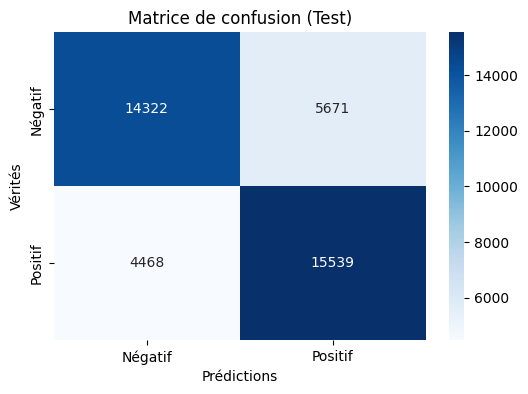

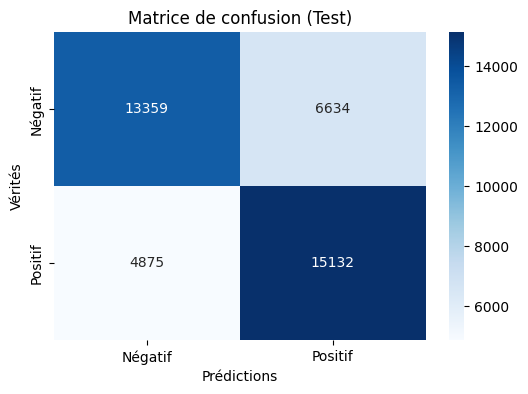

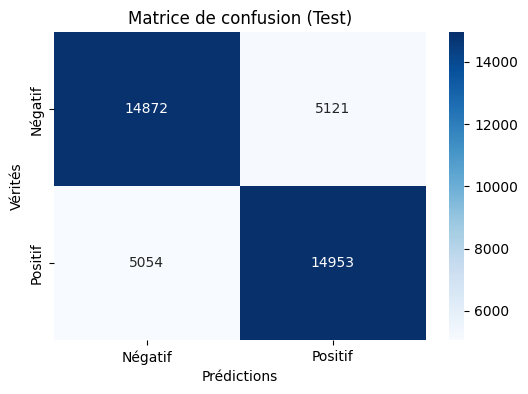

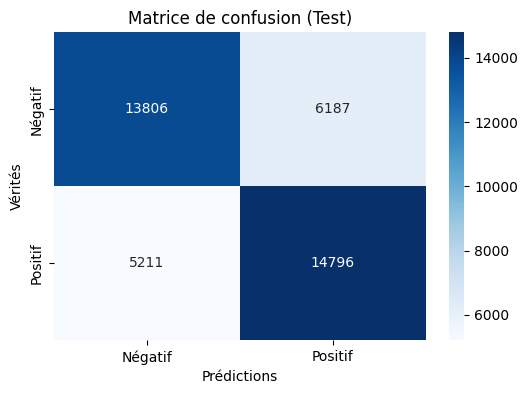

In [24]:
for name,_ in vec.items():
  # Activation de MLFlow
  with mlflow.start_run(experiment_id='880161166231324753', run_name=f"{name}"):
    # Instance de régression logistique
    model = LogisticRegressionCV( max_iter = 1000, random_state=42)

    # Enregistrer les hyperparamètres
    mlflow.log_param("model_type", "LogisticRegressionCV")
    mlflow.log_param("max_iter", 1000)

    # Validation croisée avec métriques supplémentaires
    accuracies = cross_val_score(model, vec[name]["train"], X_train.target, cv=5, scoring="accuracy")
    recalls = cross_val_score(model, vec[name]["train"], X_train.target, cv=5, scoring=make_scorer(recall_score))
    f1_scores = cross_val_score(model, vec[name]["train"], X_train.target, cv=5, scoring="f1")

    # Pour le ROC AUC, il faut une méthode adaptée pour les probabilités
    roc_aucs = cross_val_score(model, vec[name]["train"], X_train.target, cv=5, scoring="roc_auc")

    # Calculer la moyenne et l'écart-type des métriques
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)
    mean_recall = np.mean(recalls)
    std_recall = np.std(recalls)
    mean_f1 = np.mean(f1_scores)
    std_f1 = np.std(f1_scores)
    mean_roc_auc = np.mean(roc_aucs)
    std_roc_auc = np.std(roc_aucs)

    # Journalisation des métriques dans MLflow
    mlflow.log_metric("accuracy_mean", mean_accuracy)
    mlflow.log_metric("accuracy_std", std_accuracy)
    mlflow.log_metric("recall_mean", mean_recall)
    mlflow.log_metric("recall_std", std_recall)
    mlflow.log_metric("f1_mean", mean_f1)
    mlflow.log_metric("f1_std", std_f1)
    mlflow.log_metric("roc_auc_mean", mean_roc_auc)
    mlflow.log_metric("roc_auc_std", std_roc_auc)

    # Entrainement
    model.fit(vec[name]["train"], X_train.target)

    # Prediction
    y_pred = model.predict(vec[name]["test"])
    y_pred_proba = model.predict_proba(vec[name]["test"])[:,1]

    test_accuracy = accuracy_score(X_test.target, y_pred)
    test_recall = recall_score(X_test.target, y_pred)
    test_f1 = f1_score(X_test.target, y_pred)
    test_roc_auc = roc_auc_score(X_test.target, y_pred_proba)

    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_f1", test_f1)
    mlflow.log_metric("test_roc_auc", test_roc_auc)

    # Matrice de confusion
    conf_matrix = confusion_matrix(X_test.target, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=["Négatif", "Positif"],
                yticklabels=["Négatif", "Positif"])
    plt.xlabel("Prédictions")
    plt.ylabel("Vérités")
    plt.title("Matrice de confusion (Test)")
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    # Résumé des métriques
    print(f"\nTest Accuracy: {test_accuracy:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-score: {test_f1:.4f}")
    print(f"Test ROC AUC: {test_roc_auc:.4f}")
    print("\nClassification Report (Test):")
    print(classification_report(X_test.target, y_pred))

    # Enregistrement du modèle final
    mlflow.sklearn.log_model(model, "LogisticRegression")

    print(f"Modèle et métrique de {name} enregistrés dans MLFlow")

In [25]:
# visualisation des logs MLFlow
mlflow.set_tracking_uri("file:///D:/tutorial-env/OCR/Projet7/mlruns")
experiments = mlflow.search_experiments()
print(experiments)
print('---------------------------------------------------------------------')
runs = mlflow.search_runs(experiment_ids=['880161166231324753'])
print(runs)

[<Experiment: artifact_location='file:///D:/tutorial-env/OCR/Projet7/mlruns/880161166231324753', creation_time=1736765872963, experiment_id='880161166231324753', last_update_time=1736765872963, lifecycle_stage='active', name='test_RL', tags={}>]
---------------------------------------------------------------------
                              run_id       experiment_id    status  \
0   8de2e8f300684260b650c322b2cf451c  880161166231324753  FINISHED   
1   b17d60e626b349eb8b71d40a257d1b47  880161166231324753  FINISHED   
2   d3a57a8b052a445aac5e45ab32b96bf8  880161166231324753  FINISHED   
3   f56405b924a5498f863e91304a1bff79  880161166231324753  FINISHED   
4   fc728a0423d942ed80d372c7f7f91aa3  880161166231324753    FAILED   
5   6b310d40054845c1b9d7528d50fc4b88  880161166231324753    FAILED   
6   bd05e5a3156a4707afd8da2e17fd0d96  880161166231324753    FAILED   
7   c0042ebf425746a1b1f66b9455c3e484  880161166231324753    FAILED   
8   f5de365d1e974d238225f748b1d9033c  8801611662313247

In [26]:
# lancement de la fenêtre MLFlow sur le port 5006
subprocess.Popen(["mlflow", "ui", "--backend-store-uri", "file:/D:/tutorial-env/OCR/Projet7/mlruns", "--port", "5006"],stdout = subprocess.PIPE, stderr = subprocess.PIPE)
time.sleep(5)
webbrowser.open("http://127.0.0.1:5006")
print("MLFlow lancé")

MLFlow lancé


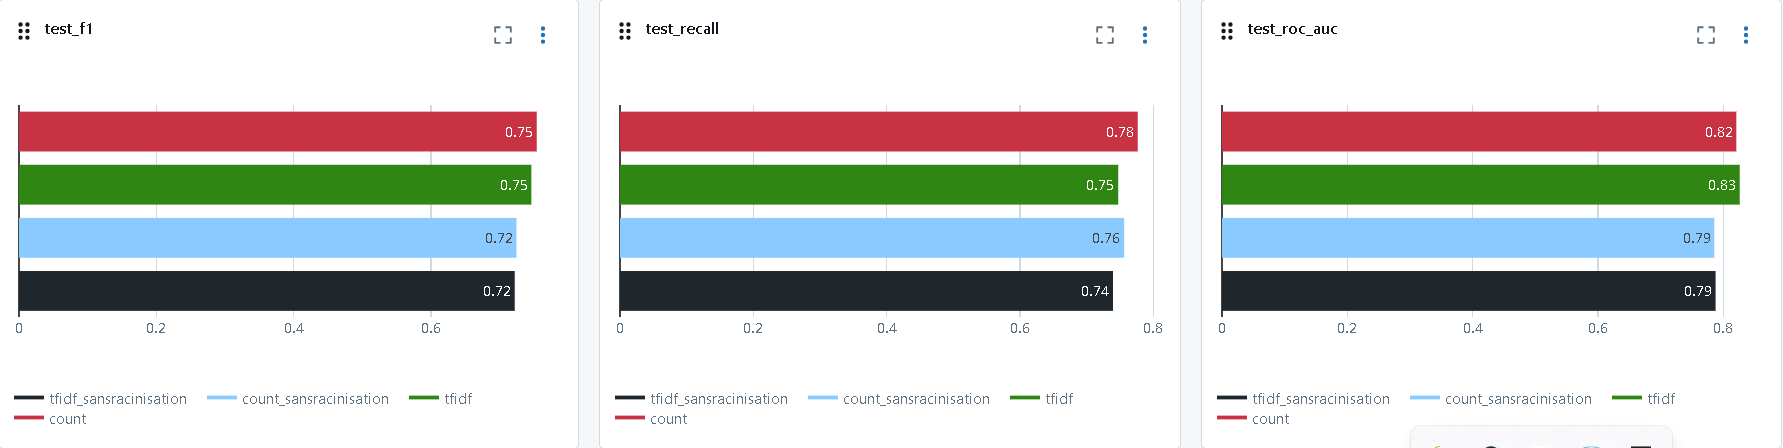

Intéressons-nous aux résultats du jeu de test :

Pour anticiper les bad buzz, nous privilégierons un fort recall et f1 score pour la classe négative 0. Cela permet de diminuer la mauvaise classification des tweets négatifs sans pour autant tout classifier en négatif.

Ainsi, les meilleurs résultats sont avec la vectorisation Tf-idf avec une racinisation par stemming avec :
- un recall de 74% pour la classe négative,
- un f1 score de 75%
- et une aire sous la courbe ROC de 0.83 (bonne capacité à distinguer les deux classes),
- la matrice de confusion montre un minimum de 5121 tweets négatifs manqués.


Voici la matrice de confusion  :

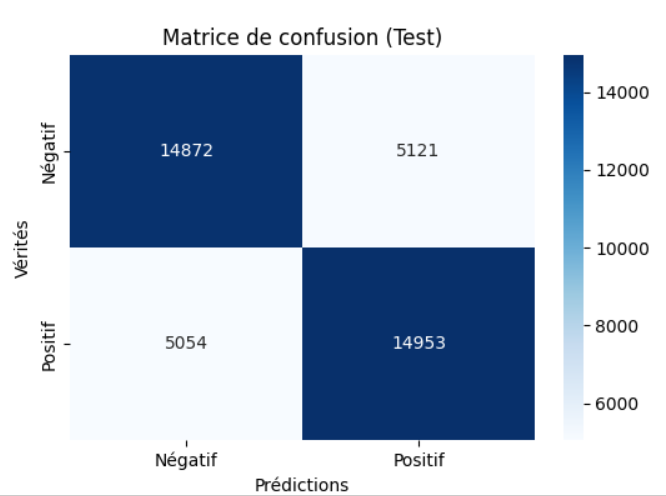

Nous avons environ 10000 faux positifs ou négatifs mais ils sont bien répartis ce qui montre une bonne généralisation.

NB : la métrique ARI n'est pas souvent adapté pour les modèles supervisés.